# LS-DYNA Parsed Model Viewer
Opens `.npy` files from `parsed_model/` and displays nodes, shells, solids, and beams.

In [13]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import Image, display

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.6g}'.format)

In [14]:
# ── Change this to your parsed output folder ──
OUTDIR = Path('parsed_model')

binary   = OUTDIR / 'binary'
plots    = OUTDIR / 'plots'
metadata = OUTDIR / 'metadata'

---
## Summary

In [15]:
with open(metadata / 'summary.json') as f:
    summary = json.load(f)

display(pd.DataFrame([summary]).T.rename(columns={0: 'value'}))

,value
source_file,frameonlyr4rgb.k
n_nodes,35639
n_shells,4392
n_solids,17940
n_beams,7816
node_columns,"[nid, x, y, z]"
shell_conn_columns,"eid,n1,n2,n3,n4,..."
solid_conn_columns,"eid,n1,n2,n3,n4,n5,n6,n7,n8,..."
beam_conn_columns,"[eid, n1, n2]"
beam_orient_columns,"[vx, vy, vz]"


---
## Nodes

In [16]:
nodes = np.load(binary / 'nodes.npy')
df_nodes = pd.DataFrame(nodes, columns=['nid', 'x', 'y', 'z'])
df_nodes['nid'] = df_nodes['nid'].astype(int)

print(f'Total nodes: {len(df_nodes):,}')
df_nodes.head(20)

Total nodes: 35,639


,nid,x,y,z
0,1,0.375,-0.15625,392.156
1,2,0.375,-0.15625,396.078
2,3,6.36,-0.15625,392.156
3,4,6.36,-0.15625,396.078
4,5,12.345,-0.15625,392.156
5,6,12.345,-0.15625,396.078
6,7,18.33,-0.15625,392.156
7,8,18.33,-0.15625,396.078
8,9,24.315,-0.15625,392.156
9,10,24.315,-0.15625,396.078


In [17]:
# Bounding box
df_nodes[['x','y','z']].agg(['min','max','mean']).T.rename(columns={'min':'min','max':'max','mean':'mean'})

,min,max,mean
x,0,2410.31,1501.49
y,-10.3125,1200,257.664
z,0,444,335.576


---
## Shell Elements

In [18]:
shell_path = binary / 'shell_conn.npy'

if shell_path.exists():
    shell_conn = np.load(shell_path)
    shell_pid  = np.load(binary / 'shell_pid.npy')

    n_node_cols = shell_conn.shape[1] - 1
    cols = ['eid'] + [f'n{i}' for i in range(1, n_node_cols + 1)]
    df_shell = pd.DataFrame(shell_conn, columns=cols)
    df_shell['pid'] = shell_pid

    print(f'Total shell elements: {len(df_shell):,}')
    print(f'Unique PIDs: {sorted(df_shell["pid"].unique())}')
    df_shell.head(20)
else:
    print('No shell elements in this model.')

Total shell elements: 4,392
Unique PIDs: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [19]:
if shell_path.exists():
    display(df_shell.groupby('pid').size().rename('count').reset_index())

,pid,count
0,1,3600
1,2,600
2,3,96
3,4,96


---
## Solid Elements

In [20]:
solid_path = binary / 'solid_conn.npy'

if solid_path.exists():
    solid_conn = np.load(solid_path)
    solid_pid  = np.load(binary / 'solid_pid.npy')

    n_node_cols = solid_conn.shape[1] - 1
    cols = ['eid'] + [f'n{i}' for i in range(1, n_node_cols + 1)]
    df_solid = pd.DataFrame(solid_conn, columns=cols)
    df_solid['pid'] = solid_pid

    print(f'Total solid elements: {len(df_solid):,}')
    print(f'Unique PIDs: {sorted(df_solid["pid"].unique())}')
    df_solid.head(20)
else:
    print('No solid elements in this model.')

Total solid elements: 17,940
Unique PIDs: [np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


In [21]:
if solid_path.exists():
    display(df_solid.groupby('pid').size().rename('count').reset_index())

,pid,count
0,5,12000
1,6,720
2,7,720
3,8,4500


---
## Beam Elements

In [22]:
beam_path = binary / 'beam_conn.npy'

if beam_path.exists():
    beam_conn   = np.load(beam_path)
    beam_pid    = np.load(binary / 'beam_pid.npy')
    beam_orient = np.load(binary / 'beam_orient.npy')

    df_beam = pd.DataFrame(beam_conn, columns=['eid', 'n1', 'n2'])
    df_beam['pid'] = beam_pid
    df_beam[['vx','vy','vz']] = beam_orient

    print(f'Total beam elements: {len(df_beam):,}')
    print(f'Unique PIDs: {sorted(df_beam["pid"].unique())}')
    df_beam.head(20)
else:
    print('No beam elements in this model.')

Total beam elements: 7,816
Unique PIDs: [np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34)]


In [23]:
if beam_path.exists():
    display(df_beam.groupby('pid').size().rename('count').reset_index())

,pid,count
0,9,2592
1,10,224
2,11,64
3,12,64
4,13,448
5,14,128
6,15,64
7,16,64
8,17,128
9,18,2592


---
## Plots

--- beams.png ---


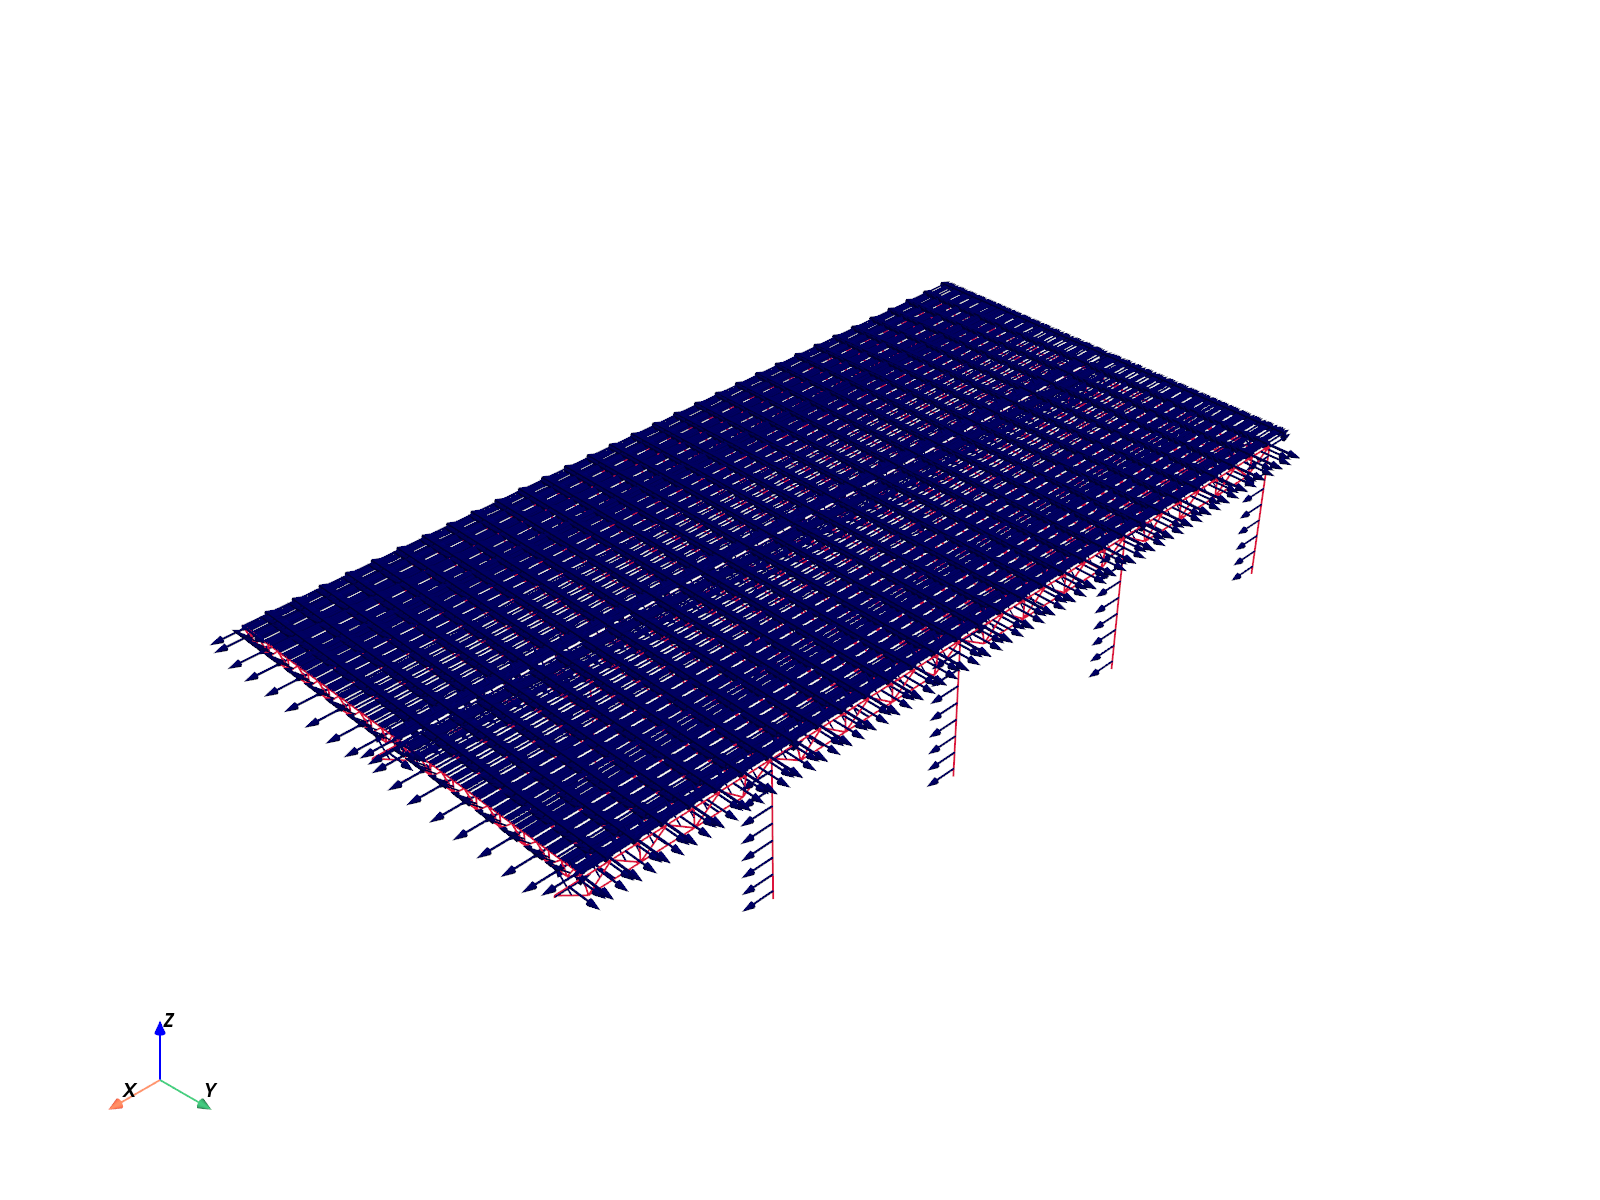

--- mesh_overview.png ---


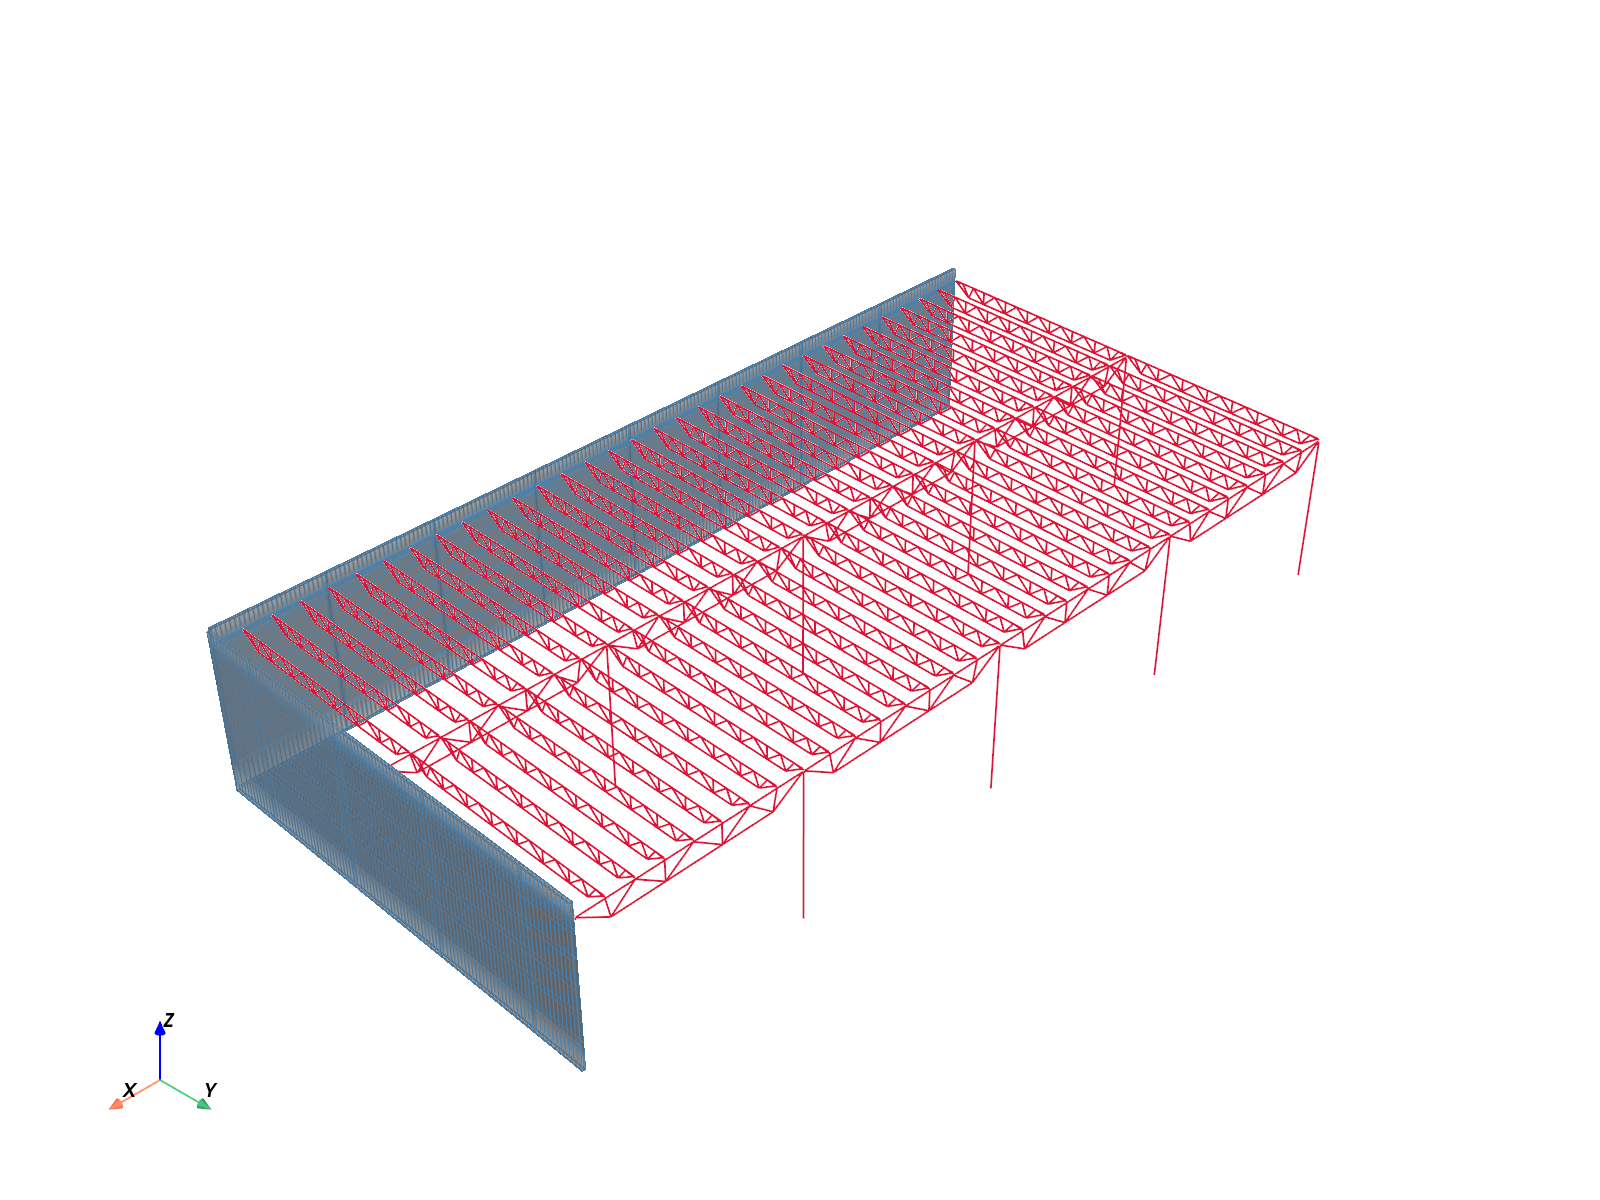

--- shells.png ---


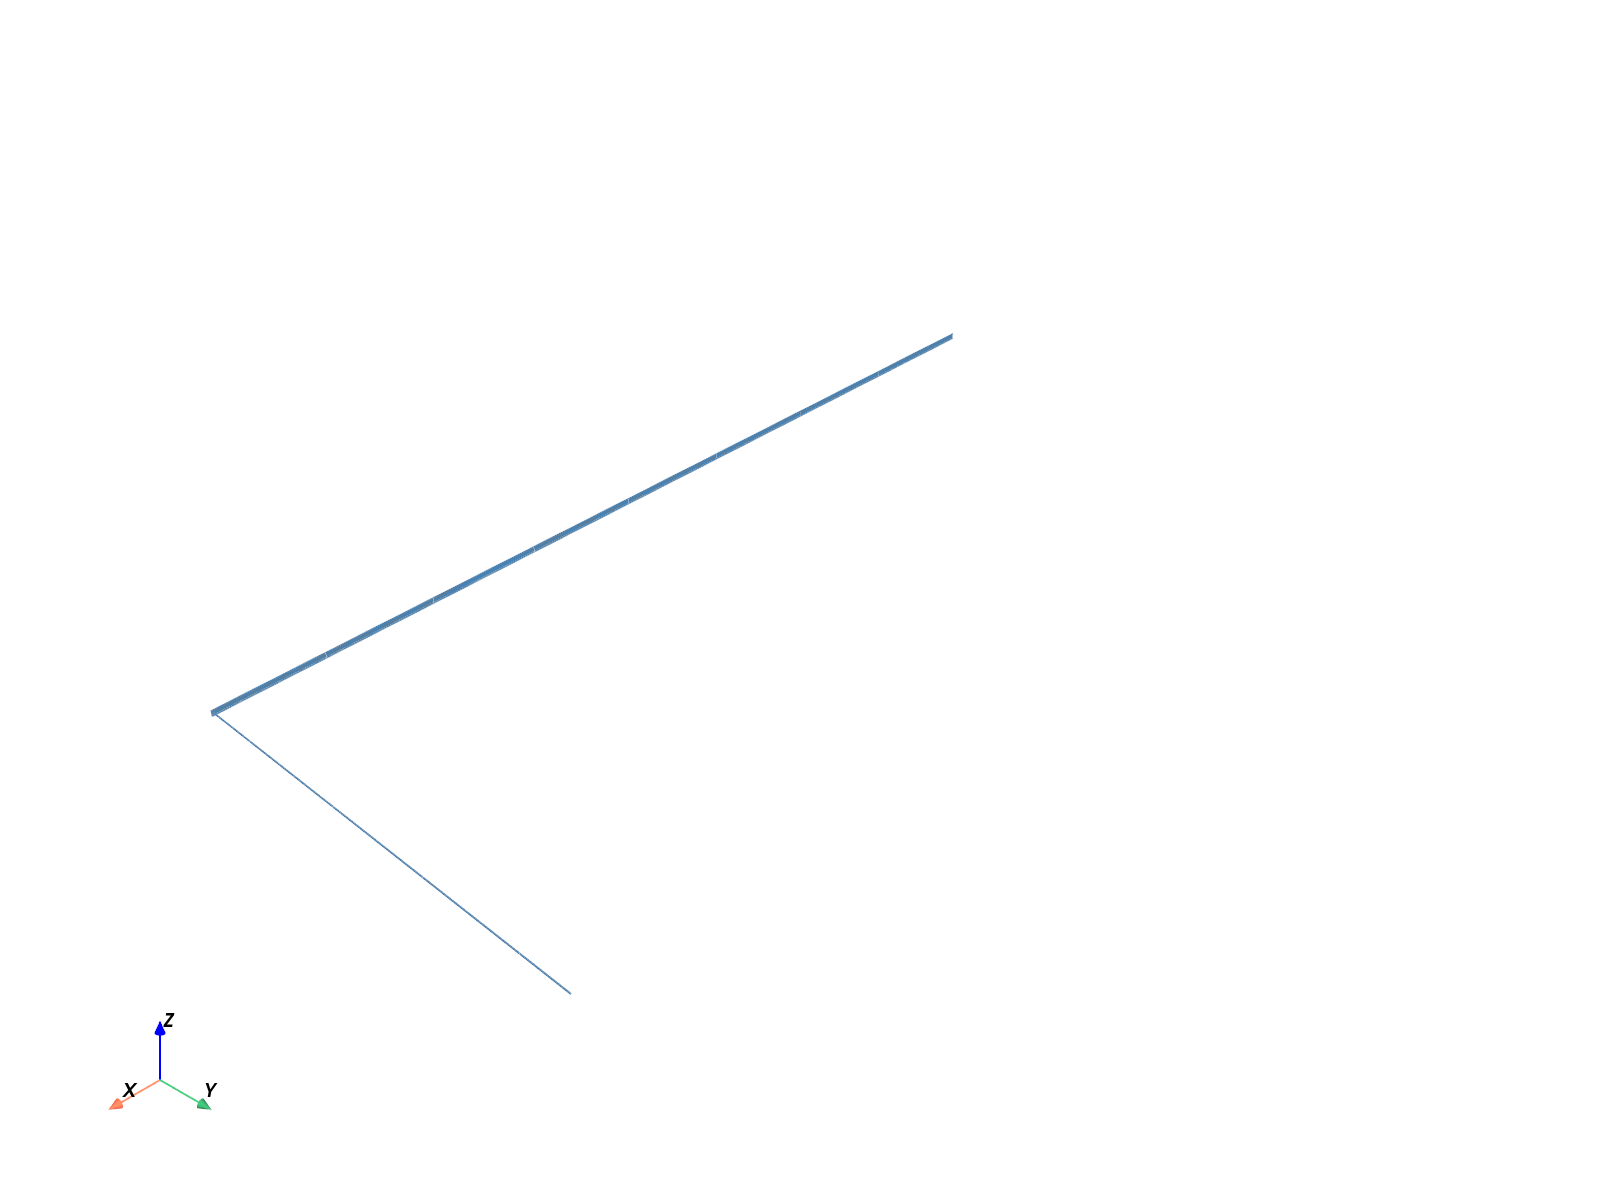

--- solids.png ---


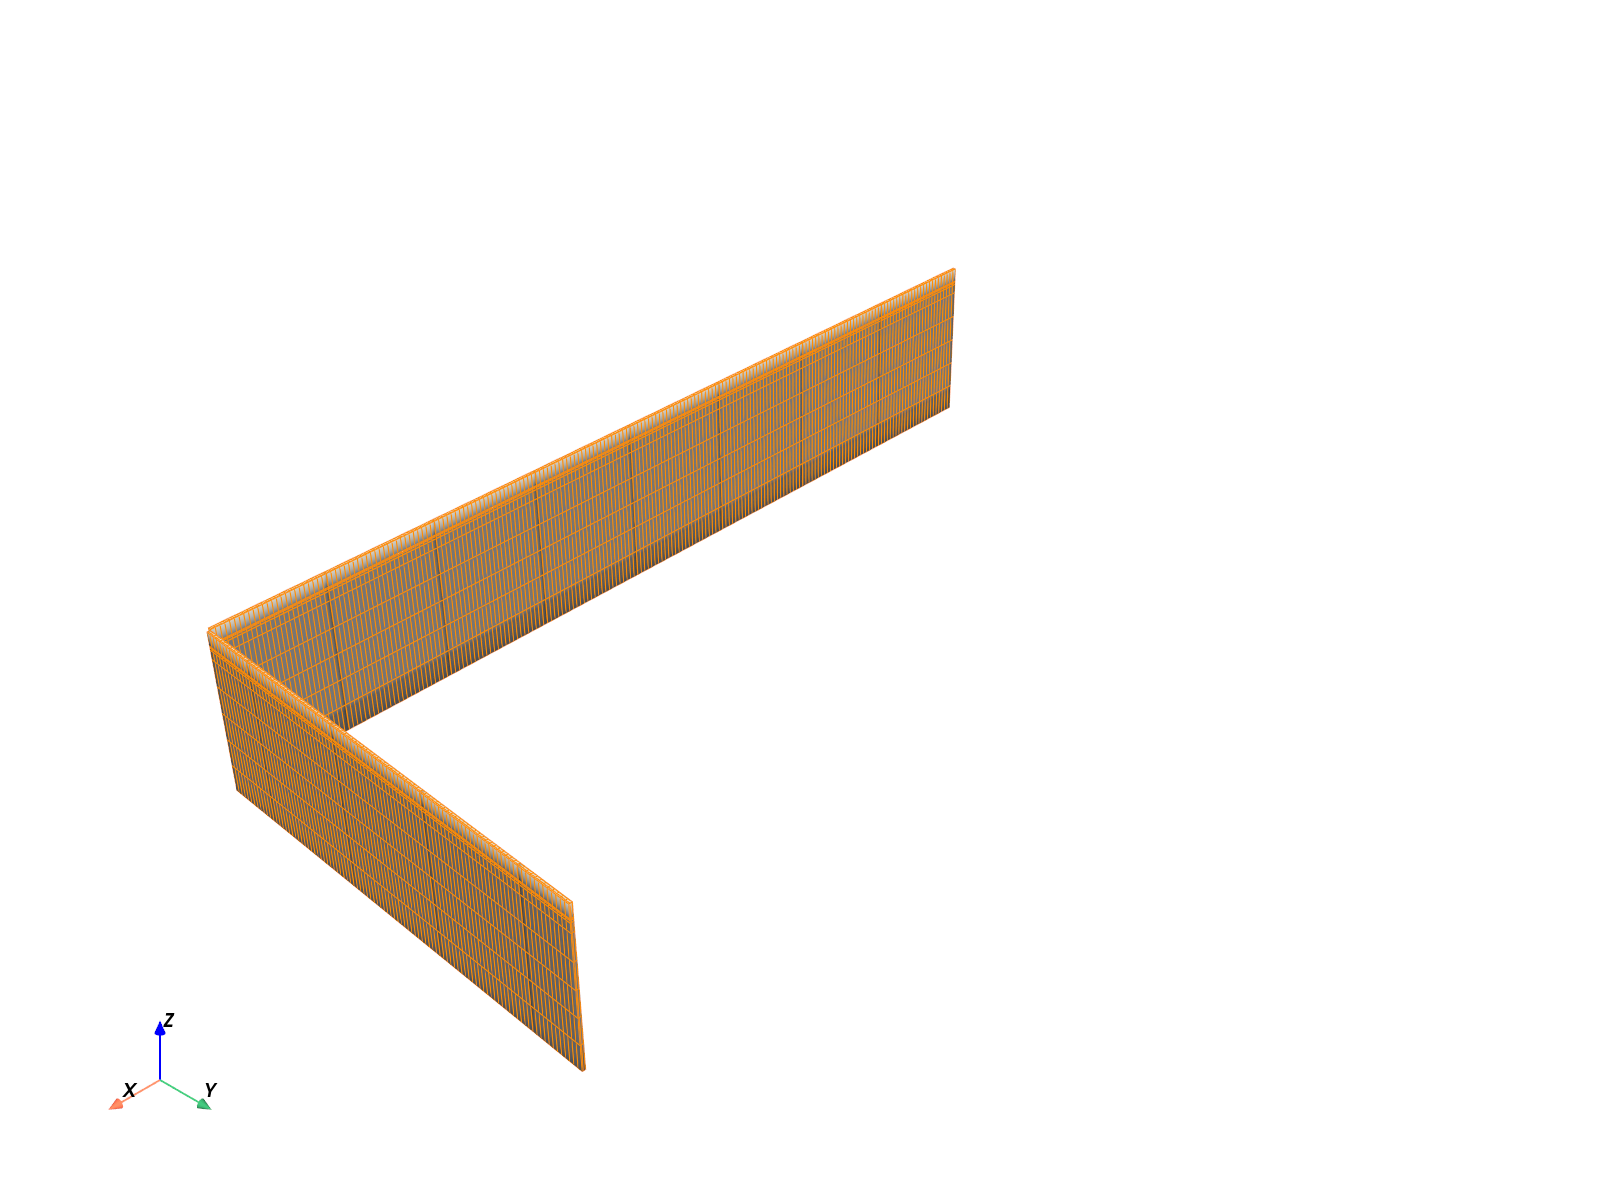

In [24]:
for png in sorted(plots.glob('*.png')):
    print(f'--- {png.name} ---')
    display(Image(filename=str(png), width=900))